### Setting imports for later code files

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

data = pd.read_csv("ufc-master.csv")

#Shows the data
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Columns: 118 entries, RedFighter to BKOOdds
dtypes: bool(1), float64(60), int64(43), object(14)
memory usage: 5.8+ MB


,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,...,FinishDetails,FinishRound,FinishRoundTime,TotalFightTimeSecs,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,Alexandre Pantoja,Kai Asakura,-250.0,215.0,40.0000,215.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,Rear Naked Choke,2.0,2:05,425.0,300.0,800.0,150.0,2500.0,400.0,350.0
1,Shavkat Rakhmonov,Ian Machado Garry,-210.0,295.0,47.6190,295.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,NaN,5.0,5:00,1500.0,250.0,650.0,180.0,3000.0,240.0,700.0
2,Ciryl Gane,Alexander Volkov,-380.0,300.0,26.3158,300.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,NaN,3.0,5:00,900.0,-160.0,450.0,1100.0,3000.0,350.0,1100.0
3,Bryce Mitchell,Kron Gracie,-950.0,625.0,10.5263,625.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,Elbows,3.0,0:39,639.0,-200.0,1100.0,380.0,1400.0,500.0,4000.0
4,Nate Landwehr,Dooho Choi,-130.0,110.0,76.9231,110.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Blue,...,Elbows,3.0,3:21,801.0,275.0,550.0,500.0,700.0,300.0,250.0


In [ ]:
data

,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,...,FinishDetails,FinishRound,FinishRoundTime,TotalFightTimeSecs,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,Alexandre Pantoja,Kai Asakura,-250.0,215.0,40.0000,215.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,Rear Naked Choke,2.0,2:05,425.0,300.0,800.0,150.0,2500.0,400.0,350.0
1,Shavkat Rakhmonov,Ian Machado Garry,-210.0,295.0,47.6190,295.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,NaN,5.0,5:00,1500.0,250.0,650.0,180.0,3000.0,240.0,700.0
2,Ciryl Gane,Alexander Volkov,-380.0,300.0,26.3158,300.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,NaN,3.0,5:00,900.0,-160.0,450.0,1100.0,3000.0,350.0,1100.0
3,Bryce Mitchell,Kron Gracie,-950.0,625.0,10.5263,625.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Red,...,Elbows,3.0,0:39,639.0,-200.0,1100.0,380.0,1400.0,500.0,4000.0
4,Nate Landwehr,Dooho Choi,-130.0,110.0,76.9231,110.0,2024-12-07,"Las Vegas, Nevada, USA",USA,Blue,...,Elbows,3.0,3:21,801.0,275.0,550.0,500.0,700.0,300.0,250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6523,Duane Ludwig,Darren Elkins,-155.0,135.0,64.5161,135.0,2010-03-21,"Broomfield, Colorado, USA",USA,Blue,...,NaN,1.0,0:44,44.0,NaN,NaN,NaN,NaN,NaN,NaN
6524,John Howard,Daniel Roberts,-210.0,175.0,47.6190,175.0,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,Punch,1.0,2:01,121.0,NaN,NaN,NaN,NaN,NaN,NaN
6525,Brendan Schaub,Chase Gormley,-260.0,220.0,38.4615,220.0,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,Punches,1.0,0:47,47.0,NaN,NaN,NaN,NaN,NaN,NaN
6526,Mike Pierce,Julio Paulino,-420.0,335.0,23.8095,335.0,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,NaN,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN


Sigmoid function - Maps the target with either 1 or 0

Logistic Regression built from scratch

In [ ]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

class LogisticRegression():

    def __init__(self, lr=0.001, n_iters=20000):
        self.lr = lr
        self.n_iters = n_iters

        #Model parameters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
      n_samples, n_features = X.shape
      self.weights = np.zeros(n_features)
      self.bias = 0

      for _ in range(self.n_iters):
        linear_pred = np.dot(X, self.weights) + self.bias
        predictions = sigmoid(linear_pred)

        dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
        db = (1 / n_samples) * np.sum(predictions - y)

        self.weights = self.weights - self.lr * dw
        self.bias = self.bias - self.lr * db

    def predict(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        y_pred = sigmoid(linear_pred)

        class_pred = [0 if y <= 0.5 else 1 for y in y_pred]
        return class_pred

Cleaning data

In [ ]:
#Convert numeric columns to actual numbers, anything invalid becomes NaN
#This is in order to avoid errors of comparing incorrect types etc string and int

cols_to_convert = [
    "RedWins", "RedLosses", "BlueWins", "BlueLosses",
    "RedWinsByKO", "BlueWinsByKO",
    "RedReachCms", "BlueReachCms",
    "RedHeightCms", "BlueHeightCms",
    "RedAge", "BlueAge",
    "RedAvgSigStrLanded", "BlueAvgSigStrLanded",
    "RedAvgTDLanded", "BlueAvgTDLanded",
    "RedLongestWinStreak", "BlueLongestWinStreak",
    "RedAvgSigStrPct", "BlueAvgSigStrPct",
    "NumberOfRounds"
]
for col in cols_to_convert:
    data[col] = pd.to_numeric(data[col], errors="coerce")



Feature Engineering

In [ ]:
#Declared features from selected dataset that we started using in the model
#Some features are calculated from info in the dataset, others are just referenced

data["win_ratio_red"] = data["RedWins"] / (data["RedWins"] + data["RedLosses"] + 1) #+1 is to prevent divition by zero
data["win_ratio_blue"] = data["BlueWins"] / (data["BlueWins"] + data["BlueLosses"] + 1)
data["win_ratio_diff"] = data["win_ratio_red"] - data["win_ratio_blue"]

data["finishes_diff"] = data["RedWinsByKO"] - data["BlueWinsByKO"]
data["rounds"] = data["NumberOfRounds"]

data["total_experience"] = (data["RedWins"] + data["RedLosses"]) + (data["BlueWins"] + data["BlueLosses"])
data["experience_ratio"] = (data["RedWins"] + 1) / (data["BlueWins"] + 1)
data["experience_diff"] = (data["RedWins"] + data["RedLosses"]) - (data["BlueWins"] + data["BlueLosses"])

data["recent_form_diff"] = (data["RedLongestWinStreak"] - data["BlueLongestWinStreak"])
data["win_rate_red"] = data["RedWins"] / (data["RedWins"] + data["RedLosses"] + 1)
data["win_rate_blue"] = data["BlueWins"] / (data["BlueWins"] + data["BlueLosses"] + 1)
data["win_rate_diff"] = data["win_rate_red"] - data["win_rate_blue"]

data["sig_str_pct_diff"] = data["RedAvgSigStrPct"] - data["BlueAvgSigStrPct"]
data["td_landed_diff"] = data["RedAvgTDLanded"] - data["BlueAvgTDLanded"]
data["longest_win_streak_diff"] = data["RedLongestWinStreak"] - data["BlueLongestWinStreak"]

data["red_odds"] = data["RedOdds"]
data["blue_odds"] = data["BlueOdds"]
data["win_dif"] = data["WinDif"]
data["loss_dif"] = data["LossDif"]
data["total_round_dif"] = data["TotalRoundDif"]
data["total_title_bout_dif"] = data["TotalTitleBoutDif"]
data["ko_dif"] = data["KODif"]
data["sub_dif"] = data["SubDif"]
data["height_dif"] = data["HeightDif"]
data["reach_dif"] = data["ReachDif"]
data["age_dif"] = data["AgeDif"]
data["winner"] = data["Winner"]

#Features to test that we believe make a difference
#These features can be changed in order to get different results
features = [
    "red_odds",
    "blue_odds",
    "reach_dif",
    "age_dif",
    "height_dif",
    "win_dif",
    "loss_dif",
    "total_round_dif",
    "total_title_bout_dif",
    "ko_dif",
    "sub_dif",
    "longest_win_streak_diff",
    "win_rate_diff",
    "experience_diff",
    "total_experience"
]
#    "sig_str_landed_diff",
#    "td_landed_diff",
#   "finishes_diff",
#    "longest_win_streak_diff",
#    "winner"
#    "win_ratio_diff",
#    "sig_str_pct_diff",
#    "rounds",
#    "total_experience",
#    "experience_ratio",
#    "experience_diff",
#    "recent_form_diff",
#    "win_rate_diff"

Prepare, split and scale

Also fill in NaN with median value

In [ ]:
data = data.sort_values(by="Date")

data["target"] = data["Winner"].apply(lambda x: 1 if x == "Red" else 0)

#Prepare X as features and y as the target
X = data[features]
y = data["target"]

#Drop missing rows, this improved the model from 59,71% to 66,21% accuracy
data_xy = pd.concat([X, y], axis=1).dropna().reset_index(drop=True)
X = data_xy.iloc[:, :-1]
y = data_xy.iloc[:, -1]

#Split data in about ~70/15/15%
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

#Scale features
#fit_transform() learns mean and standard deviation
#transform() applies scaling to validation and test to avoiddata leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


### Compare custom model with sklearn model, and check feature correlation
Prints graphs showing the accuracy of the different models


---------------Custom Logistic Regression---------------
Test Accuracy:               66.21%
Validation Accuracy:         64.72%

---------------Sklearn Logistic Regression ---------------
Test Accuracy:               66.31%

---------------Random Forest Classifier ---------------
Test Accuracy:               65.89%
Validation Accuracy:         64.51%

-------------------Model Comparison -------------------
Our Logistic Regression:     66.21%
Sklearn Logistic Regression: 66.31%
Random Forest:               65.89%


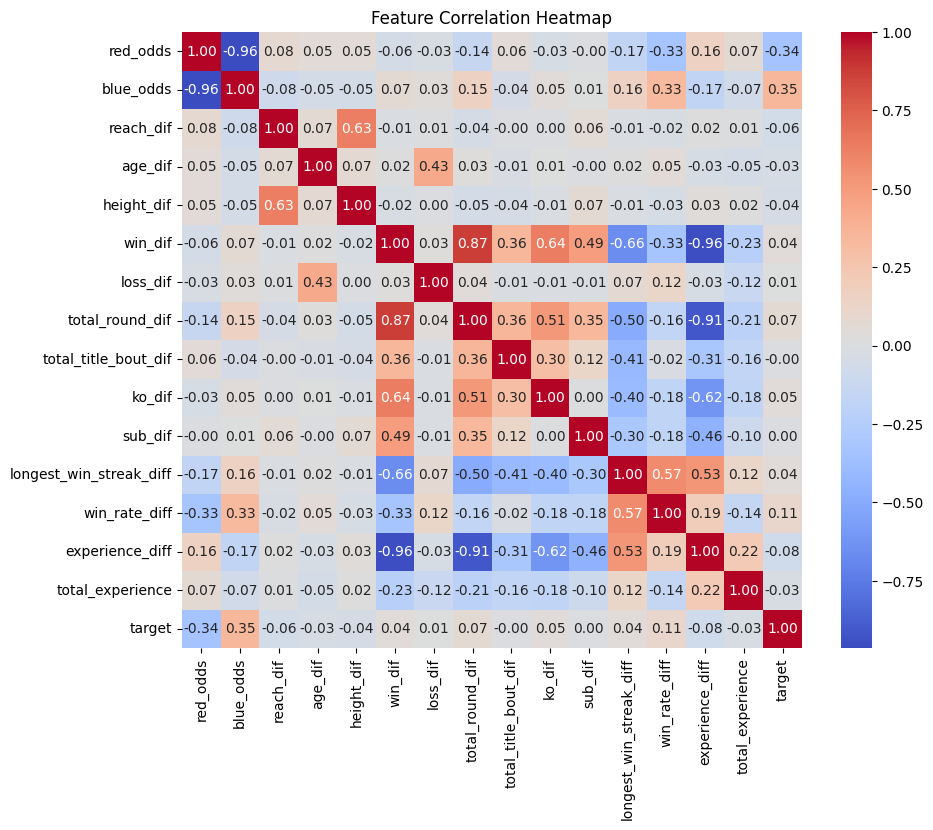

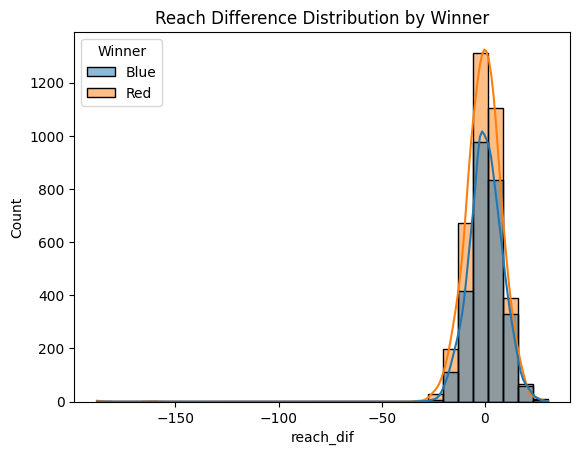

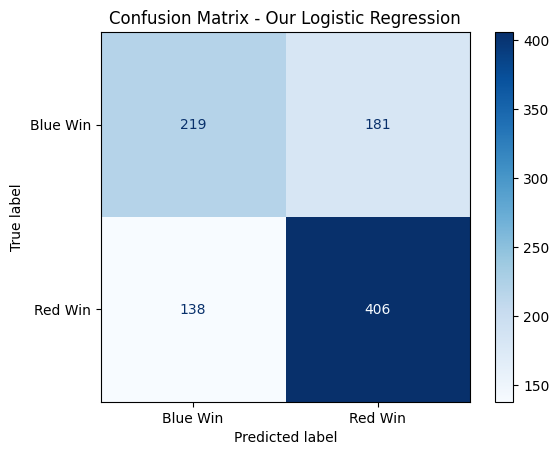

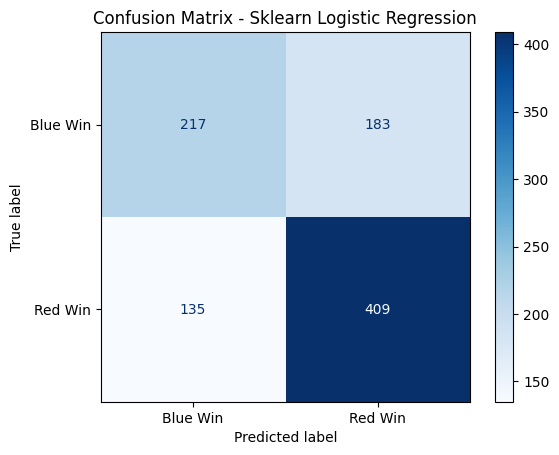

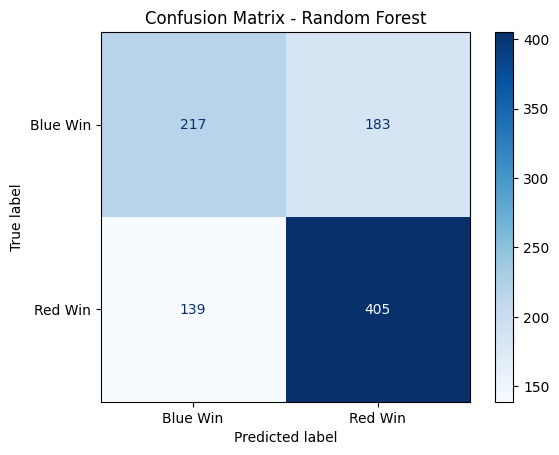

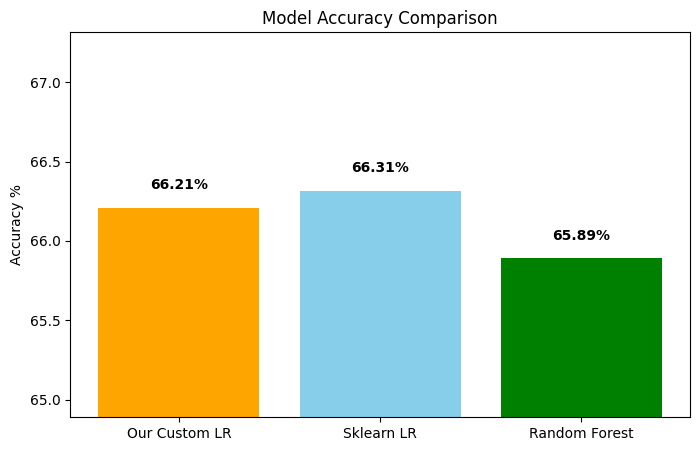

In [ ]:
#Custom Logistic Regression Model
custom_model = LogisticRegression(lr=0.001, n_iters=10000)
custom_model.fit(X_train, y_train)

custom_preds = custom_model.predict(X_test)
custom_acc = np.mean(custom_preds == y_test)

val_preds = custom_model.predict(X_val)
val_acc = np.mean(val_preds == y_val)

print("\n---------------Custom Logistic Regression---------------")
print(f"Test Accuracy:               {custom_acc * 100:.2f}%")
print(f"Validation Accuracy:         {val_acc * 100:.2f}%")

#Sklearn Logistic Regression
sk_model = SkLogReg(max_iter=5000)
sk_model.fit(X_train, y_train)
sk_acc = sk_model.score(X_test, y_test)

print("\n---------------Sklearn Logistic Regression ---------------")
print(f"Test Accuracy:               {sk_acc * 100:.2f}%")

#Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_acc = np.mean(rf_model.predict(X_test) == y_test)
rf_val_acc = np.mean(rf_model.predict(X_val) == y_val)

print("\n---------------Random Forest Classifier ---------------")
print(f"Test Accuracy:               {rf_acc * 100:.2f}%")
print(f"Validation Accuracy:         {rf_val_acc * 100:.2f}%")

#Model Comparison
print("\n-------------------Model Comparison -------------------")
print(f"Our Logistic Regression:     {custom_acc * 100:.2f}%")
print(f"Sklearn Logistic Regression: {sk_acc * 100:.2f}%")
print(f"Random Forest:               {rf_acc * 100:.2f}%")

#Feature correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = data[features + ["target"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

#Histogram
sns.histplot(data=data, x="reach_dif", hue="Winner", bins=30, kde=True)
plt.title("Reach Difference Distribution by Winner")
plt.show()

#Confusion matrix
models = {
    "Our Logistic Regression": custom_model,
    "Sklearn Logistic Regression": sk_model,
    "Random Forest": rf_model
}

#Confusion matrix
for name, model in models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Blue Win", "Red Win"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


accuracies = {
    "Our Custom LR": custom_acc,
    "Sklearn LR": sk_acc,
    "Random Forest": rf_acc
}

# Convert to percentages
models = list(accuracies.keys())
values = [v * 100 for v in accuracies.values()]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, values, color=["orange", "skyblue", "green"])

#Add text labels above each bar
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.1, f"{value:.2f}%",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylabel("Accuracy %")
plt.title("Model Accuracy Comparison")

#Make differences more visible
plt.ylim(min(values) - 1, max(values) + 1)

plt.show()